# Notebook 1 : Data Preprocessing, Feature Selection and Exploration
### Nutrition Intelligence System | Predicting Protein, Fat, and Sugar in Foods



---


---
<a id='1'></a>
## 0. Imports & loading

In this part, we begin by importing the required libraries, then specifying the file paths and loading the CSV files

***Files:***
we have 4 files:



*   food.csv:containes information about the food like id and description
*   nurient.csv:contains all the nutrients,their ids and units
*   food_nutrient:contains the nutrient in each food and their amount +other data
*  food_category:here we have the specification of the category












In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
# File paths in  drive
file_path_food = '/content/drive/MyDrive/nutri_project/data/food.csv'
file_path_food_nutri = '/content/drive/MyDrive/nutri_project/data/food_nutrient.csv'
file_nutri = '/content/drive/MyDrive/nutri_project/data/nutrient.csv'
file_cat = '/content/drive/MyDrive/nutri_project/data/food_category.csv'
# Load svs for each file
food = pd.read_csv(file_path_food)
food_nutrient = pd.read_csv(file_path_food_nutri, on_bad_lines='skip', engine='python')
nutrient = pd.read_csv(file_nutri)
food_category = pd.read_csv(file_cat)



Mounted at /content/drive




For the next part,we discover the data shape number of rows and columns ,see a sample of the data (few lines) and the number of empty values


In [2]:
print("food:", food.shape)
print("food_nutrient:", food_nutrient.shape)
print("nutrient:", nutrient.shape)
print("food_category:", food_category.shape)

food: (7793, 5)
food_nutrient: (644125, 11)
nutrient: (474, 5)
food_category: (28, 3)


In [3]:
print("food.csv")
print(food.head(10))
print("\nfood_category.csv ")
print(food_category.head(10))
print("\nnutrient.csv ")
print(nutrient.head(20))
print("\nfood_nutrient.csv")
print(food_nutrient.head(10))

food.csv
   fdc_id       data_type                                        description  \
0  167512  sr_legacy_food  Pillsbury Golden Layer Buttermilk Biscuits, Ar...   
1  167513  sr_legacy_food  Pillsbury, Cinnamon Rolls with Icing, refriger...   
2  167514  sr_legacy_food  Kraft Foods, Shake N Bake Original Recipe, Coa...   
3  167515  sr_legacy_food     George Weston Bakeries, Thomas English Muffins   
4  167516  sr_legacy_food         Waffles, buttermilk, frozen, ready-to-heat   
5  167517  sr_legacy_food  Waffle, buttermilk, frozen, ready-to-heat, toa...   
6  167518  sr_legacy_food  Waffle, buttermilk, frozen, ready-to-heat, mic...   
7  167519  sr_legacy_food    Waffle, plain, frozen, ready-to-heat, microwave   
8  167520  sr_legacy_food  Pie Crust, Cookie-type, Graham Cracker, Ready ...   
9  167521  sr_legacy_food     Pie Crust, Cookie-type, Chocolate, Ready Crust   

   food_category_id publication_date  
0                18       2019-04-01  
1                18       2019-0

In [4]:
print("food.csv nulls")
print(food.isnull().sum())

print("food_nutrient.csv nulls ")
print(food_nutrient.isnull().sum())

print("nutrient.csv nulls")
print(nutrient.isnull().sum())

print("food_category.csv nulls")
print(food_category.isnull().sum())

food.csv nulls
fdc_id              0
data_type           0
description         0
food_category_id    0
publication_date    0
dtype: int64
food_nutrient.csv nulls 
id                        0
fdc_id                    0
nutrient_id               0
amount                    0
data_points               0
derivation_id        181743
min                  547234
max                  547232
median               644125
footnote             643861
min_year_acquired    644125
dtype: int64
nutrient.csv nulls
id               0
name             0
unit_name        0
nutrient_nbr    12
rank            11
dtype: int64
food_category.csv nulls
id             0
code           0
description    0
dtype: int64


<a id='3'></a>
## 1. Data Preprocessing

Before training any model, the data needs to be cleaned and prepared.We folloed these steps
### 1.1 all data
1. Choose the columns to keep for each file seperatly
2. For nutrient removing irrelevant or leaky nutrient
3. Removing nutrients that doesn't exist in food_nutrient
4. Merging food data with category data
5. Pivoting food_nutrient data and assigning names instead of ids
6. Merging the the pivoted data with the previously merged data

### 1.2 Original Data(no nulls)
1. Encoding Category
2. Removing food id Column


### 1.3 Corrupted Data(Notebook 2)
1. Data corruption(for testing)
2. Rediscovering dirty data
3. Cleaning data and filling missing values
4. Removing outliers from targets
5. Encoding Category
6. Removing food id Column  
**Full implementation available here:**  
[Open Corrupted Data Notebook](https://colab.research.google.com/drive/1mgeUtIiRPSejkq5LtNtOXqR1rNF4I6vB#scrollTo=w4yJIJT5bs4E)

### 1.1.1 Choose the columns to keep for each file seperatly

For each file we create dataframe copy and we keep only the columns that we need and the are relevant to our project for example in nutrient.csv we do not keep nutrient_nbr or rank, since these are internal metrics used by the dataset creators to organize the data


In [5]:
#step 1: select only needed columns
#for food nutrient we need to know the food and the amount of each nutrients in it
food_nutrient_clean1 = food_nutrient[['fdc_id', 'nutrient_id', 'amount']].copy()
#nutrient we need id ,name and unit name to be able to noramlize the columns later
nutrient_clean1 = nutrient[['id', 'name','unit_name']].copy()
#the food id and the id for its category
food_clean1 = food[['fdc_id', 'food_category_id']].copy()
#food category id and description(the category itself)
food_category_clean1 = food_category[['id', 'description']].copy()
#keeping description for food seperatly to be able to identify what is the food
food_description = food[['fdc_id', 'description']].copy()
#shape after selecting columns
print("food_nutrient_clean:", food_nutrient_clean1.shape)
print("nutrient_clean:", nutrient_clean1.shape)
print("food_clean:", food_clean1.shape)
print("food_category_clean:", food_category_clean1.shape)

food_nutrient_clean: (644125, 3)
nutrient_clean: (474, 3)
food_clean: (7793, 2)
food_category_clean: (28, 2)


In [6]:
#check nutrient to see what we can keep or remove
print(nutrient_clean1[['id', 'name', 'unit_name']].to_string())

       id                                                                  name unit_name
0    2047                                      Energy (Atwater General Factors)      KCAL
1    2048                                     Energy (Atwater Specific Factors)      KCAL
2    1001                                                                Solids         G
3    1002                                                              Nitrogen         G
4    1003                                                               Protein         G
5    1004                                                     Total lipid (fat)         G
6    1005                                           Carbohydrate, by difference         G
7    1006                                  Fiber, crude (DO NOT USE - Archived)         G
8    1007                                                                   Ash         G
9    1008                                                                Energy      KCAL
10   1009 

### 1.1.2 Removing irrelevant or leaky data from nutrient

Among all the nutrients we have that are many that we either don't need like  Flavonoids,pigments,archived nutrient(specified do not use),some vitamins , duplicates or nutrients we should not use like subcomponents of sugar ,protein and fat that can cause data leakage.


In [7]:

ids_to_remove  = [
    1008, 2047, 2048, 1062,
    1085, 1053, 1054,
    1063, 1010, 1011, 1012, 1013, 1014,
    1258, 1257, 1292, 1293, 1329, 1330, 1331,
    1006, 1066, 1148,
    1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034,
    1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042, 1043,
    1044, 1045, 1046, 1047, 1048,
    1336, 1337, 1338, 1339,
    1340, 1341, 1342, 1343, 1344, 1345, 1346, 1347, 1348,
    1349, 1350, 1351, 1352, 1353, 1354, 1355, 1356, 1357,
    1358, 1359, 1360, 1361, 1362, 1363, 1364, 1365, 1366,
    1367, 1368, 1369, 1370, 1371, 1372, 1373, 1374, 1375,
    1376, 1377, 1378, 1379, 1380, 1381, 1382, 1383, 1384,
    1385, 1386, 1387, 1388, 1389, 1390, 1391, 1392, 1393,
    1394, 1395, 1396, 1397, 1398,1210, 1211, 1212, 1213, 1214,
    1215, 1216, 1217, 1218, 1219,
    1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228,
    1259, 1260, 1261, 1262, 1263, 1264, 1265, 1266, 1267,
    1268, 1269, 1270, 1271, 1272, 1273, 1274, 1275, 1276, 1277,
    1278, 1279, 1280, 1283, 1285, 1286, 1288, 1299, 1300, 1301,
    1303, 1304, 1305, 1306, 1307, 1310, 1311, 1312, 1313, 1314,
    1315, 1316, 1317, 1321, 1323, 1325, 1332, 1333, 1404, 1405,
    1406, 1408, 1409, 1410, 1411,1412,
    1075,1110, 1104, 1111, 1112, 1186, 1187, 1190,1105, 1183, 1184, 1246, 1242
]

#for food nutrient we kept only the nutrient that ar enot in ids to removed
food_nutrient_clean2 = food_nutrient_clean1[
    ~food_nutrient_clean1['nutrient_id'].isin(ids_to_remove)
].copy()
#same as food nutrient
nutrient_clean2 = nutrient_clean1[
    ~nutrient_clean1['id'].isin(ids_to_remove)
].copy()
#see the difference in the shape
print("food_nutrient before:", food_nutrient_clean1.shape)
print("food_nutrient after:", food_nutrient_clean2.shape)
print("nutrients that exist in food_nutrient:", food_nutrient_clean2['nutrient_id'].nunique())

print("\nnutrient before:", nutrient_clean1.shape)
print("nutrient after:", nutrient_clean2.shape)

food_nutrient before: (644125, 3)
food_nutrient after: (275520, 3)
nutrients that exist in food_nutrient: 49

nutrient before: (474, 3)
nutrient after: (278, 3)


### 1.1.3 Removing nutrients that doesn't exist in food_nutrient

We notice from previous result that number of nutrient is 278 while only 49 exist in food_nutrient so we keep only the 49

In [8]:
existing_nutrient_ids = food_nutrient_clean2['nutrient_id'].unique()

nutrient_clean3 = nutrient_clean2[
    nutrient_clean2['id'].isin(existing_nutrient_ids)
].copy()

print("nutrient after:", nutrient_clean3.shape)

nutrient after: (49, 3)


### 1.1.4 Merging food data with category data

For this step we merge the food dataset with food category file , the point is to get for each food id what the description of the category

In [9]:
#merging food and category table using ids and keeping all data
food_merged = food_clean1.merge(
    food_category_clean1,
    left_on='food_category_id',
    right_on='id',
    how='left'
)
#removing the ids later since we don't need them
food_merged = food_merged.drop(columns=['id', 'food_category_id'])

print(food_merged.head())
print(food_merged.shape)

   fdc_id     description
0  167512  Baked Products
1  167513  Baked Products
2  167514  Baked Products
3  167515  Baked Products
4  167516  Baked Products
(7793, 2)


In [10]:
print(food_merged.isna().sum())

fdc_id         0
description    0
dtype: int64


### 1.1.5 Pivoting food_nutrient data and assigning names instead of ids

In this step, we pivot the food_nutrient data from a vertical format to a horizontal format. Initially, the dataset contains multiple rows for the same food ID, each associated with a different nutrient ID and its corresponding amount.After pivoting, each food ID appears only once, with all available nutrients represented as separate columns. The values in these columns correspond to the nutrient amounts, and 0 is assigned when a nutrient is not present for a given food item.

In [11]:
#pivot the table to get each food with the amount of the nutrients
food_nutrient_pivoted = food_nutrient_clean2.pivot_table(
    index='fdc_id',  # each row one food
    columns='nutrient_id', # each nutrient becomes a column
    values='amount',   # the value in the amount
    fill_value=0   # fill missing nutrients with 0
).reset_index()
# diectionnary to map ids to names
nutrient_map = dict(zip(nutrient_clean3['id'], nutrient_clean3['name']))

# Rename the columns using the map
food_nutrient_pivoted = food_nutrient_pivoted.rename(columns=nutrient_map)

print(food_nutrient_pivoted.head(5))

nutrient_id  fdc_id  Protein  Total lipid (fat)  Carbohydrate, by difference  \
0            167512     5.88              13.24                        41.18   
1            167513     4.34              11.27                        53.42   
2            167514     6.10               3.70                        79.80   
3            167515     8.00               1.80                        46.00   
4            167516     6.58               9.22                        41.05   

nutrient_id   Ash  Starch  Alcohol, ethyl  Water  Caffeine  Theobromine  ...  \
0            3.50    0.00             0.0  35.50       0.0          0.0  ...   
1            3.08    0.00             0.0  27.86       0.0          0.0  ...   
2            7.20    0.00             0.0   3.20       0.0          0.0  ...   
3            1.60    0.00             0.0  42.60       0.0          0.0  ...   
4            2.81   35.51             0.0  40.34       0.0          0.0  ...   

nutrient_id  Niacin  Pantothenic acid 

### 1.1.6.final Merge

In this step, we merge the pivoted data containing food nutrients and the one containing the food categories combining them into one dataframe

In [12]:
#final merge between the food with the specified nutrient and category
merged_data_food = food_merged.merge(
    food_nutrient_pivoted,
    on='fdc_id',
    how='left'
)

print(merged_data_food.head(10))
print(merged_data_food.shape)

   fdc_id     description  Protein  Total lipid (fat)  \
0  167512  Baked Products     5.88              13.24   
1  167513  Baked Products     4.34              11.27   
2  167514  Baked Products     6.10               3.70   
3  167515  Baked Products     8.00               1.80   
4  167516  Baked Products     6.58               9.22   
5  167517  Baked Products     7.42               9.49   
6  167518  Baked Products     6.92               9.40   
7  167519  Baked Products     6.71               9.91   
8  167520  Baked Products     5.10              24.83   
9  167521  Baked Products     6.08              22.42   

   Carbohydrate, by difference   Ash  Starch  Alcohol, ethyl  Water  Caffeine  \
0                        41.18  3.50    0.00             0.0  35.50       0.0   
1                        53.42  3.08    0.00             0.0  27.86       0.0   
2                        79.80  7.20    0.00             0.0   3.20       0.0   
3                        46.00  1.60    0.00    

In [13]:
print(merged_data_food.isnull().sum())

fdc_id                            0
description                       0
Protein                           0
Total lipid (fat)                 0
Carbohydrate, by difference       0
Ash                               0
Starch                            0
Alcohol, ethyl                    0
Water                             0
Caffeine                          0
Theobromine                       0
Fiber, total dietary              0
Calcium, Ca                       0
Iron, Fe                          0
Magnesium, Mg                     0
Phosphorus, P                     0
Potassium, K                      0
Sodium, Na                        0
Zinc, Zn                          0
Copper, Cu                        0
Fluoride, F                       0
Manganese, Mn                     0
Selenium, Se                      0
Vitamin A, RAE                    0
Carotene, beta                    0
Carotene, alpha                   0
Vitamin E (alpha-tocopherol)      0
Vitamin D (D2 + D3)         

In [14]:
targets = ['Protein', 'Total lipid (fat)', 'Sugars, Total']

print("Current max values in merged_data_food:")
print(merged_data_food[targets].max())

print("\nCurrent shape:")
print(merged_data_food.shape)

Current max values in merged_data_food:
Protein               88.32
Total lipid (fat)    100.00
Sugars, Total         99.80
dtype: float64

Current shape:
(7793, 51)


In [15]:
# save right after merging, before ANY cleaning
merged_data_food.to_csv('merged_raw.csv', index=False)

# then work on a copy
df_merged = merged_data_food.copy()

In [16]:
merged_data_food.duplicated().sum()

np.int64(0)

### 1.1.7.Removing outliers from targets

In this step, we remove any value that is abnormally far from other values Standard IQR uses 1.5 but nutritional data has legitimate extreme foods so we increase the threshold based on skewness to keep natural high values while still removing true outliers

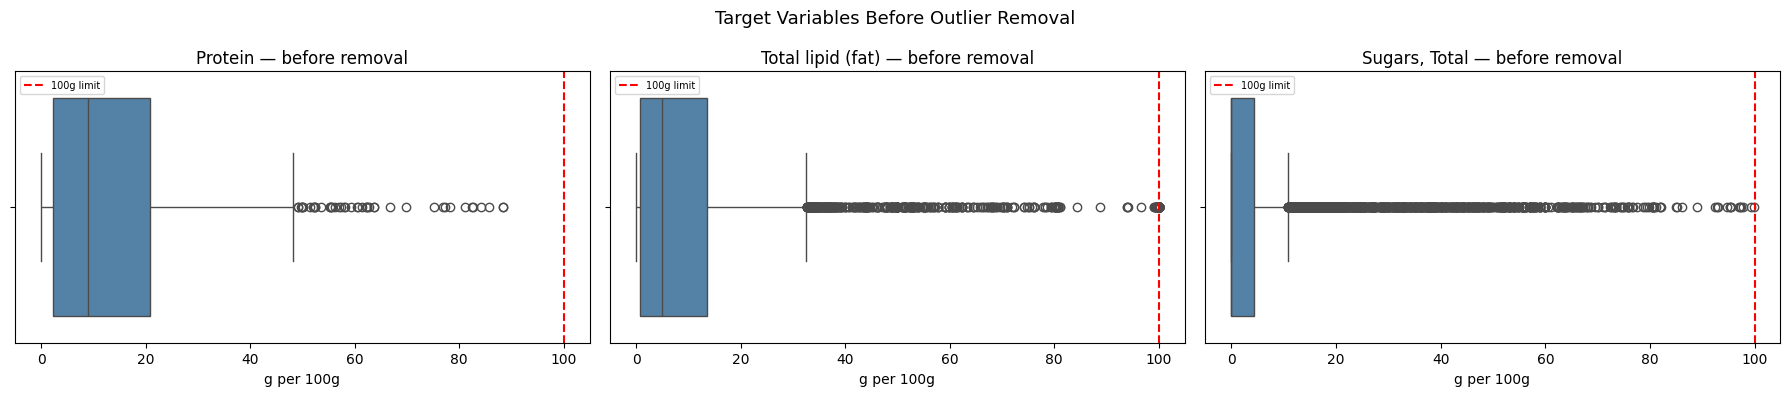

Protein: values above 100g = 0
Total lipid (fat): values above 100g = 0
Sugars, Total: values above 100g = 0


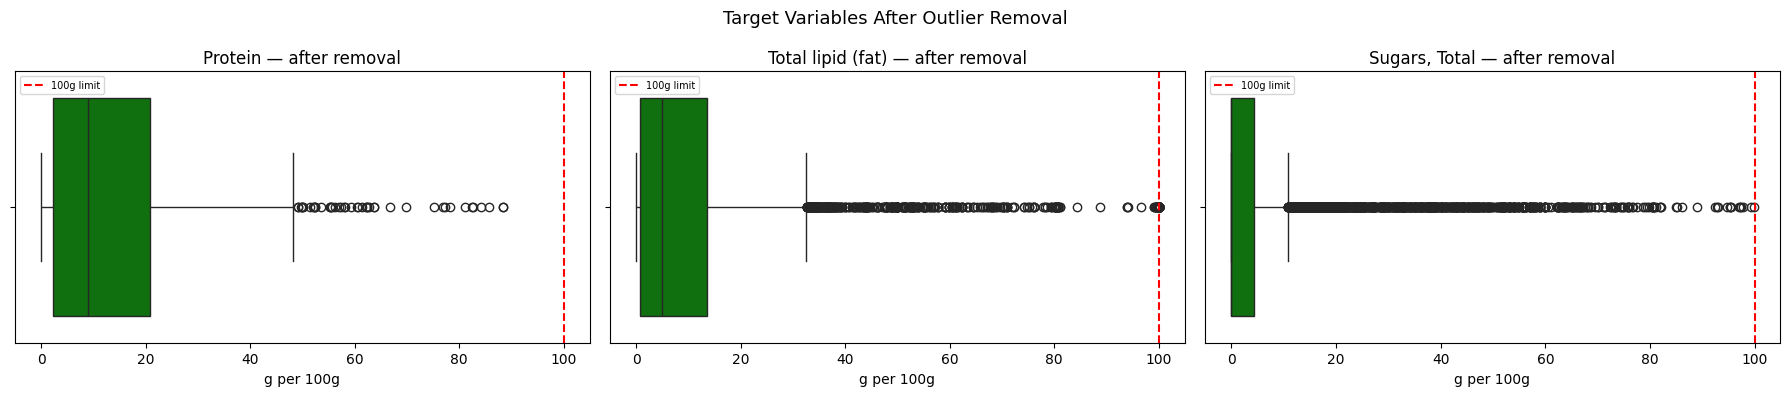


Before: (7793, 51)
After:  (7793, 51)
Removed: 0


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

targets = ['Protein', 'Total lipid (fat)', 'Sugars, Total']
domain_upper = 100

# show boxplots before removal
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(targets):
    sns.boxplot(x=df_merged[col], ax=axes[i], color='steelblue')
    axes[i].axvline(x=domain_upper, color='red', linestyle='--', label='100g limit')
    axes[i].set_title(f'{col} — before removal')
    axes[i].set_xlabel('g per 100g')
    axes[i].legend(fontsize=7)
plt.suptitle('Target Variables Before Outlier Removal', fontsize=13)
plt.tight_layout()
plt.show()

# remove outliers using threshold 100
#we are working on 100g per food the values can not exceed these threshold
mask = pd.Series([True] * len(df_merged))
for col in targets:
    removed = (df_merged [col] > domain_upper).sum()
    print(f"{col}: values above 100g = {removed}")
    mask = mask & (df_merged [col] <= domain_upper)

df_clean1 = df_merged[mask].reset_index(drop=True)

# show boxplots after removal
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(targets):
    sns.boxplot(x=df_clean1[col], ax=axes[i], color='green')
    axes[i].axvline(x=domain_upper, color='red', linestyle='--', label='100g limit')
    axes[i].set_title(f'{col} — after removal')
    axes[i].set_xlabel('g per 100g')
    axes[i].legend(fontsize=7)
plt.suptitle('Target Variables After Outlier Removal', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nBefore: {df_merged.shape}")
print(f"After:  {df_clean1.shape}")
print(f"Removed: {len(df_merged) - len(df_clean1)}")

Although no values exceeded the 100g domain threshold, boxplots still show statistical outliers. These values are not errors but represent rare but valid foods that's why no domain-based outlier removal was necessary

In [19]:
from scipy.stats import skew
nutrient_cols = df_clean1.columns[2:]
skewness = df_clean1[nutrient_cols].skew().sort_values(ascending=False)
print(skewness)

Copper, Cu                        85.902104
Vitamin D (D2 + D3)               58.447885
Caffeine                          48.121114
Manganese, Mn                     37.583387
Selenium, Se                      37.486618
Tocopherol, beta                  36.530844
Cryptoxanthin, beta               36.448616
Vitamin C, total ascorbic acid    29.689655
Theobromine                       28.368160
Carotene, alpha                   27.552980
Thiamin                           24.769750
Tocotrienol, delta                24.709552
Vitamin A, RAE                    23.179866
Lycopene                          22.865737
Sodium, Na                        21.878189
Betaine                           20.825244
Carotene, beta                    18.800976
Phosphorus, P                     18.740516
Tocotrienol, alpha                18.690782
Fluoride, F                       18.107925
Alcohol, ethyl                    17.233286
Ash                               17.107489
Tocopherol, delta               

In [20]:
print(df_clean1.isna().sum())

fdc_id                            0
description                       0
Protein                           0
Total lipid (fat)                 0
Carbohydrate, by difference       0
Ash                               0
Starch                            0
Alcohol, ethyl                    0
Water                             0
Caffeine                          0
Theobromine                       0
Fiber, total dietary              0
Calcium, Ca                       0
Iron, Fe                          0
Magnesium, Mg                     0
Phosphorus, P                     0
Potassium, K                      0
Sodium, Na                        0
Zinc, Zn                          0
Copper, Cu                        0
Fluoride, F                       0
Manganese, Mn                     0
Selenium, Se                      0
Vitamin A, RAE                    0
Carotene, beta                    0
Carotene, alpha                   0
Vitamin E (alpha-tocopherol)      0
Vitamin D (D2 + D3)         

# **Note:**
 Since My Data doesn't contain any null values i downloaded the data and  corrupted it using AI


In [ ]:
#df_clean1.to_csv('original_food_dataset.csv', index=False)
#from google.colab import files  # only in Colab
#files.download('original_food_dataset.csv')

In [ ]:
print(df_clean1.dtypes)

## 1.2 Original Data
### 1.2.1 Encoding Category

For the original dataset, we encode the category into numerical values by creating one column per category. One column is dropped to avoid redundancy, as we can deduced from the others.

In [ ]:
df_food_encoded = pd.get_dummies(df_clean1, columns=['description'], prefix='cat', drop_first=True)

In [ ]:
df_food_encoded

In [ ]:
#because the new columns were encoded as true false
#select the columns
dummy_cols = [col for col in df_food_encoded.columns if col.startswith('cat_')]
# Convert  them to 0 and 1
df_food_encoded[dummy_cols] = df_food_encoded[dummy_cols].astype(int)
print(df_food_encoded[dummy_cols].head())

### 1.2.2 Removing food id
After encoding the category the last step is to remove the food id since it has no effect on our prediction.

In [ ]:
final_original_food_data = df_food_encoded.drop(columns=['fdc_id'])

In [ ]:
print(final_original_food_data.shape)

In [ ]:
final_original_food_data.to_csv('final_original_food_dataset.csv', index=False)
from google.colab import files  # only in Colab
#.download('final_original_food_dataset.csv')